# ETA prediction cho mot tuyen xe buyt co dinh

Notebook nay doc `sample.csv`, thuc hien EDA, danh gia cac mo hinh phu hop va chon model du doan `delta_time` cho cap diem co dinh trong du lieu.

**Ket luan ky thuat mong doi:** vi `stationId`, `destination_stationId` va toa do deu gan nhu hang so, tin hieu du doan chinh con lai la `hour`. Do do notebook uu tien benchmark co baseline ro rang va chi chon mo hinh phuc tap neu no thang baseline tren cross-validation.

In [18]:
from __future__ import annotations

from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
plt.style.use('ggplot')


## 1. Doc du lieu

In [19]:
if Path('data/sample.csv').exists():
    PROJECT_ROOT = Path('.').resolve()
    DATA_PATH = PROJECT_ROOT / 'data' / 'sample.csv'
elif Path('sample.csv').exists():
    PROJECT_ROOT = Path('..').resolve()
    DATA_PATH = Path('sample.csv').resolve()
else:
    raise FileNotFoundError('Khong tim thay sample.csv. Hay chay notebook tu root project hoac tu thu muc data/.')

df = pd.read_csv(DATA_PATH)
df.head()


,stationId,destination_stationId,hour,lat,lng,destination_lat,destination_lng,delta_time
0,1992,323,14,10.872419,106.768248,10.875454,106.758689,141.879610
1,1992,323,16,10.872419,106.768248,10.875454,106.758689,214.738806
2,1992,323,18,10.872419,106.768248,10.875454,106.758689,131.112207
3,1992,323,14,10.872419,106.768248,10.875454,106.758689,197.674791
4,1992,323,7,10.872419,106.768248,10.875454,106.758689,191.282736


In [20]:
print(f'Dataset path: {DATA_PATH}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
display(df.dtypes.to_frame('dtype'))
display(df.isna().sum().to_frame('missing_values'))
display(df.nunique().to_frame('unique_values'))


Dataset path: D:\vinAI\GSM\Map\ETA-prediction\data\sample.csv
Shape: 309 rows x 8 columns


,dtype
stationId,int64
destination_stationId,int64
hour,int64
lat,float64
lng,float64
destination_lat,float64
destination_lng,float64
delta_time,float64


,missing_values
stationId,0
destination_stationId,0
hour,0
lat,0
lng,0
destination_lat,0
destination_lng,0
delta_time,0


,unique_values
stationId,1
destination_stationId,1
hour,18
lat,1
lng,1
destination_lat,1
destination_lng,1
delta_time,309


## 2. Kiem tra chat luong du lieu va tuyen duong


In [21]:
required_columns = {
    'stationId', 'destination_stationId', 'hour', 'lat', 'lng',
    'destination_lat', 'destination_lng', 'delta_time'
}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f'Missing required columns: {sorted(missing_columns)}')

df = df.copy()
numeric_columns = ['stationId', 'destination_stationId', 'hour', 'lat', 'lng', 'destination_lat', 'destination_lng', 'delta_time']
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

if df[numeric_columns].isna().any().any():
    display(df[numeric_columns].isna().sum().to_frame('missing_after_numeric_cast'))
    raise ValueError('Co gia tri khong ep kieu numeric duoc trong cac cot bat buoc.')

if not df['hour'].between(0, 23).all():
    raise ValueError('Cot hour co gia tri nam ngoai khoang [0, 23].')

route_columns = ['stationId', 'destination_stationId', 'lat', 'lng', 'destination_lat', 'destination_lng']
display(df[route_columns].drop_duplicates())
display(df.describe().T)


,stationId,destination_stationId,lat,lng,destination_lat,destination_lng
0,1992,323,10.872419,106.768248,10.875454,106.758689


,count,mean,std,min,25%,50%,75%,max
stationId,309.0,1992.000000,0.000000e+00,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000
destination_stationId,309.0,323.000000,0.000000e+00,323.000000,323.000000,323.000000,323.000000,323.000000
hour,309.0,13.223301,4.621938e+00,4.000000,8.000000,16.000000,17.000000,21.000000
lat,309.0,10.872419,1.779238e-15,10.872419,10.872419,10.872419,10.872419,10.872419
lng,309.0,106.768248,1.423391e-14,106.768248,106.768248,106.768248,106.768248,106.768248
destination_lat,309.0,10.875454,3.558476e-15,10.875454,10.875454,10.875454,10.875454,10.875454
destination_lng,309.0,106.758689,0.000000e+00,106.758689,106.758689,106.758689,106.758689,106.758689
delta_time,309.0,188.304376,7.680745e+01,74.199850,143.994139,170.172401,208.990548,891.276558


## 3. EDA target `delta_time`

In [22]:
target = df['delta_time']
q1, q3 = target.quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outlier_mask = (target < lower_bound) | (target > upper_bound)

summary = pd.DataFrame({
    'metric': ['mean', 'median', 'std', 'min', 'p25', 'p75', 'max', 'iqr_lower_bound', 'iqr_upper_bound', 'n_iqr_outliers'],
    'value': [target.mean(), target.median(), target.std(), target.min(), q1, q3, target.max(), lower_bound, upper_bound, int(outlier_mask.sum())],
})
display(summary)
display(df.loc[outlier_mask].sort_values('delta_time', ascending=False).head(10))


,metric,value
0,mean,188.304376
1,median,170.172401
2,std,76.807447
3,min,74.199850
4,p25,143.994139
5,p75,208.990548
6,max,891.276558
7,iqr_lower_bound,46.499525
8,iqr_upper_bound,306.485162
9,n_iqr_outliers,18.000000


,stationId,destination_stationId,hour,lat,lng,destination_lat,destination_lng,delta_time
20,1992,323,18,10.872419,106.768248,10.875454,106.758689,891.276558
237,1992,323,16,10.872419,106.768248,10.875454,106.758689,534.211356
222,1992,323,17,10.872419,106.768248,10.875454,106.758689,481.953571
187,1992,323,17,10.872419,106.768248,10.875454,106.758689,464.346872
67,1992,323,16,10.872419,106.768248,10.875454,106.758689,463.685515
155,1992,323,7,10.872419,106.768248,10.875454,106.758689,447.148806
79,1992,323,17,10.872419,106.768248,10.875454,106.758689,407.100183
42,1992,323,16,10.872419,106.768248,10.875454,106.758689,403.212852
294,1992,323,17,10.872419,106.768248,10.875454,106.758689,364.237320
154,1992,323,18,10.872419,106.768248,10.875454,106.758689,361.549488


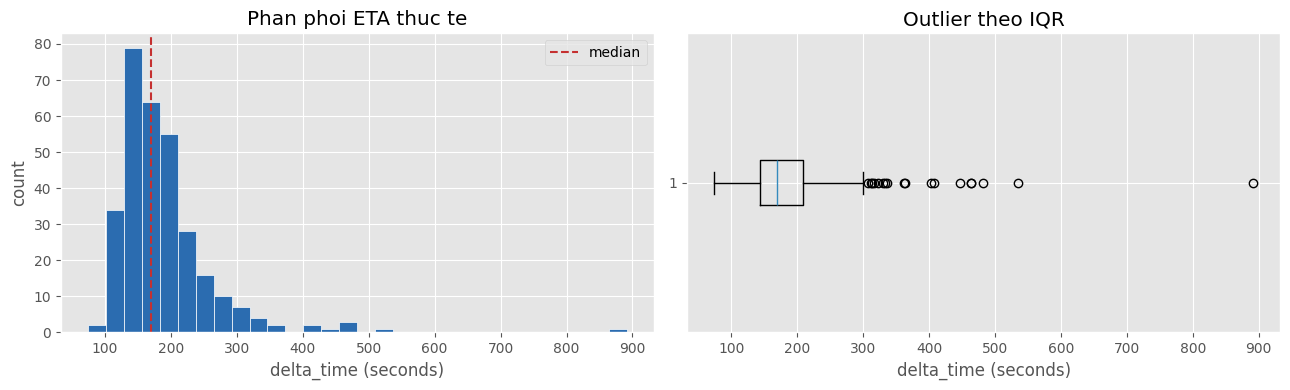

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['delta_time'], bins=30, color='#2b6cb0', edgecolor='white')
axes[0].axvline(df['delta_time'].median(), color='#c53030', linestyle='--', label='median')
axes[0].set_title('ETA Distribution')
axes[0].set_xlabel('delta_time (seconds)')
axes[0].set_ylabel('count')
axes[0].legend()

axes[1].boxplot(df['delta_time'], vert=False)
axes[1].set_title('Outlier theo IQR')
axes[1].set_xlabel('delta_time (seconds)')
plt.tight_layout()
plt.show()


## 4. EDA theo gio trong ngay

,hour,count,mean,median,std,min,max
0,4,5,135.74,128.16,28.20,105.69,172.53
1,5,16,157.20,150.86,38.63,110.28,248.29
2,6,21,181.95,167.00,52.49,100.51,333.94
3,7,24,191.55,174.34,74.79,116.23,447.15
4,8,12,168.61,154.92,42.02,125.12,266.93
5,9,5,209.39,215.30,33.93,170.38,254.50
6,10,13,179.23,197.43,56.99,74.20,254.95
7,11,6,165.53,165.81,26.37,135.10,207.27
8,12,7,151.03,145.98,24.62,116.92,186.25
9,13,15,157.16,156.70,34.91,112.86,265.85


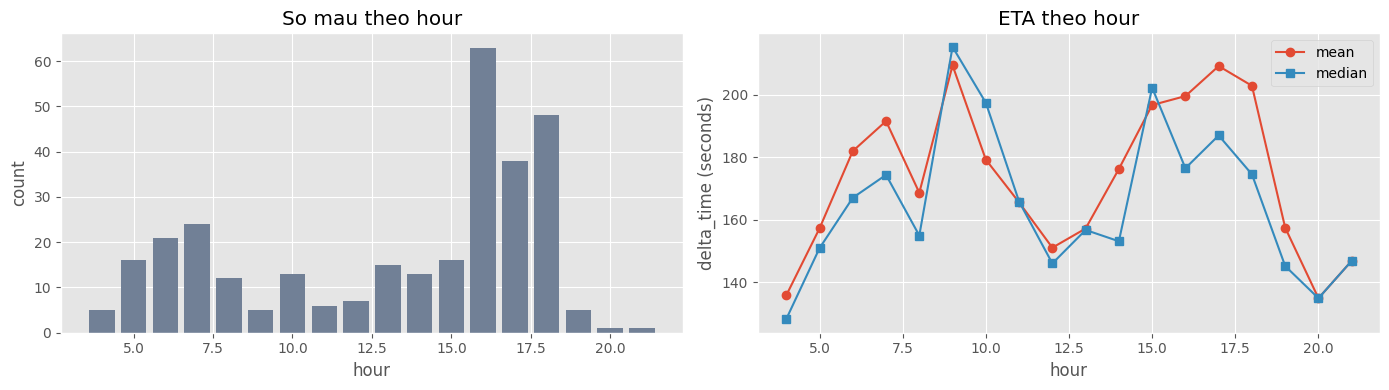

In [24]:
hour_summary = (
    df.groupby('hour')['delta_time']
    .agg(count='count', mean='mean', median='median', std='std', min='min', max='max')
    .reset_index()
)
display(hour_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(hour_summary['hour'], hour_summary['count'], color='#718096')
axes[0].set_title('So mau theo hour')
axes[0].set_xlabel('hour')
axes[0].set_ylabel('count')

axes[1].plot(hour_summary['hour'], hour_summary['mean'], marker='o', label='mean')
axes[1].plot(hour_summary['hour'], hour_summary['median'], marker='s', label='median')
axes[1].set_title('ETA theo hour')
axes[1].set_xlabel('hour')
axes[1].set_ylabel('delta_time (seconds)')
axes[1].legend()
plt.tight_layout()
plt.show()


## 5. Feature engineering

Feature hop ly voi du lieu hien tai:

- `hour` dang categorical va dang chu ky qua `hour_sin`, `hour_cos`.
- Cac co `is_morning_peak`, `is_evening_peak`, `is_late` de mo ta cac khung gio co the tac dong den ETA.
- Khoang cach Haversine chi duoc dung de audit vi cap diem trong file la co dinh, nen no gan nhu hang so va khong co gia tri du doan noi bo tap nay.

In [25]:
def haversine_meters(lat1, lng1, lat2, lng2):
    radius_m = 6_371_000
    lat1_rad = np.radians(lat1)
    lat2_rad = np.radians(lat2)
    dlat = np.radians(lat2 - lat1)
    dlng = np.radians(lng2 - lng1)
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlng / 2) ** 2
    return 2 * radius_m * np.arcsin(np.sqrt(a))

def make_features(raw: pd.DataFrame) -> pd.DataFrame:
    features = pd.DataFrame(index=raw.index)
    features['hour'] = raw['hour'].astype(int)
    features['hour_sin'] = np.sin(2 * np.pi * features['hour'] / 24)
    features['hour_cos'] = np.cos(2 * np.pi * features['hour'] / 24)
    features['is_morning_peak'] = features['hour'].between(6, 8).astype(int)
    features['is_evening_peak'] = features['hour'].between(16, 18).astype(int)
    features['is_late'] = features['hour'].between(19, 23).astype(int)
    return features

df['haversine_distance_meters'] = haversine_meters(
    df['lat'], df['lng'], df['destination_lat'], df['destination_lng']
)
X = make_features(df)
y = df['delta_time']

display(df[['haversine_distance_meters']].describe().T)
display(X.head())


,count,mean,std,min,25%,50%,75%,max
haversine_distance_meters,309.0,1097.025948,2.277425e-13,1097.025948,1097.025948,1097.025948,1097.025948,1097.025948


,hour,hour_sin,hour_cos,is_morning_peak,is_evening_peak,is_late
0,14,-0.500000,-8.660254e-01,0,0,0
1,16,-0.866025,-5.000000e-01,0,1,0
2,18,-1.000000,-1.836970e-16,0,1,0
3,14,-0.500000,-8.660254e-01,0,0,0
4,7,0.965926,-2.588190e-01,1,0,0


## 6. Benchmark mo hinh

Do khong co timestamp thu tu thoi gian trong `sample.csv`, ta dung `KFold(shuffle=True)` de danh gia on dinh hon tren tap nho. Neu sau nay co `request_timestamp`, nen doi sang chronological split hoac `TimeSeriesSplit`.

Ngoai du doan diem, notebook them quantile P50/P85/P90. P50 la ETA trung vi, P85/P90 la ETA thận trọng hon: muc P90 co nghia ky vong khoang 90% chuyen xe co ETA thuc te nho hon hoac bang nguong nay neu model duoc calibrated tot.

In [26]:
from model.eta_models import HourMedianRegressor, HourQuantileRegressor, pinball_loss


ridge_preprocess = ColumnTransformer(
    transformers=[
        ('hour_one_hot', OneHotEncoder(handle_unknown='ignore'), ['hour']),
        ('scaled_numeric', StandardScaler(), ['hour_sin', 'hour_cos', 'is_morning_peak', 'is_evening_peak', 'is_late']),
    ],
    remainder='drop',
)

models = {
    'Dummy median': DummyRegressor(strategy='median'),
    'Hour median': HourMedianRegressor(),
    'Ridge': Pipeline([('preprocess', ridge_preprocess), ('model', Ridge(alpha=1.0))]),
    'RandomForest': RandomForestRegressor(n_estimators=300, min_samples_leaf=8, random_state=RANDOM_STATE),
    'HistGradientBoosting': HistGradientBoostingRegressor(max_iter=150, learning_rate=0.05, max_leaf_nodes=7, l2_regularization=0.1, random_state=RANDOM_STATE),
}

try:
    from xgboost import XGBRegressor
    models['XGBoost'] = XGBRegressor(
        n_estimators=120,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='reg:squarederror',
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
except ImportError:
    print('xgboost chua duoc cai dat; bo qua XGBoost.')

quantiles = [0.50, 0.85, 0.90]
quantile_models = {}
for q in quantiles:
    label = f'P{int(q * 100)}'
    quantile_models[f'Hour quantile {label}'] = HourQuantileRegressor(quantile=q)
    quantile_models[f'GB quantile {label}'] = GradientBoostingRegressor(
        loss='quantile',
        alpha=q,
        n_estimators=120,
        max_depth=2,
        learning_rate=0.05,
        min_samples_leaf=8,
        random_state=RANDOM_STATE,
    )

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2',
}

rows = []
for name, model in models.items():
    cv_result = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=None)
    rows.append({
        'model': name,
        'cv_mae_mean': -cv_result['test_mae'].mean(),
        'cv_mae_std': cv_result['test_mae'].std(),
        'cv_rmse_mean': -cv_result['test_rmse'].mean(),
        'cv_r2_mean': cv_result['test_r2'].mean(),
    })

results_df = pd.DataFrame(rows).sort_values('cv_mae_mean').reset_index(drop=True)
display(results_df.round(4))

quantile_rows = []
for model_name, model in quantile_models.items():
    q = 0.50 if 'P50' in model_name else 0.85 if 'P85' in model_name else 0.90
    fold_losses = []
    fold_coverages = []
    fold_mean_over = []
    for train_index, test_index in cv.split(X):
        fitted = clone(model).fit(X.iloc[train_index], y.iloc[train_index])
        pred = fitted.predict(X.iloc[test_index])
        actual = y.iloc[test_index].to_numpy()
        fold_losses.append(pinball_loss(actual, pred, q))
        fold_coverages.append(np.mean(actual <= pred))
        fold_mean_over.append(np.mean(pred - actual))
    quantile_rows.append({
        'model': model_name,
        'quantile': q,
        'cv_pinball_loss_mean': np.mean(fold_losses),
        'cv_coverage_mean': np.mean(fold_coverages),
        'target_coverage': q,
        'coverage_gap': np.mean(fold_coverages) - q,
        'mean_pred_minus_actual_seconds': np.mean(fold_mean_over),
    })

quantile_results_df = pd.DataFrame(quantile_rows).sort_values(['quantile', 'cv_pinball_loss_mean']).reset_index(drop=True)
display(quantile_results_df.round(4))


,model,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_r2_mean
0,Dummy median,46.8801,5.6798,76.6371,-0.0648
1,Hour median,49.4708,3.1840,77.5133,-0.1109
2,XGBoost,49.8814,3.9124,75.6384,-0.0542
3,RandomForest,49.9208,3.9373,75.7247,-0.0566
4,HistGradientBoosting,49.9499,3.9797,75.7450,-0.0579
5,Ridge,49.9966,3.8535,75.7661,-0.0599


,model,quantile,cv_pinball_loss_mean,cv_coverage_mean,target_coverage,coverage_gap,mean_pred_minus_actual_seconds
0,GB quantile P50,0.50,24.4477,0.5113,0.50,0.0113,-14.6938
1,Hour quantile P50,0.50,24.7354,0.5114,0.50,0.0114,-13.1100
2,GB quantile P85,0.85,20.0966,0.8447,0.85,-0.0053,51.2957
3,Hour quantile P85,0.85,20.8439,0.8026,0.85,-0.0474,47.6855
4,GB quantile P90,0.90,16.6945,0.8869,0.90,-0.0131,72.1214
5,Hour quantile P90,0.90,17.6566,0.8576,0.90,-0.0424,67.2963


## 7. Chon model va danh gia holdout

Metric chinh la MAE vi ETA co outlier lon. `Dummy median` duoc giu lam global baseline, nhung model deploy khong nen la hang so neu da co input `hour`; do do notebook chon model non-dummy co CV MAE tot nhat cho point ETA.


In [27]:
cv_best_model_name = results_df.loc[0, 'model']
deployable_results_df = results_df[results_df['model'] != 'Dummy median'].reset_index(drop=True)
best_model_name = deployable_results_df.loc[0, 'model'] if len(deployable_results_df) else cv_best_model_name
selection_policy = 'best_non_dummy_hour_aware_model' if best_model_name != cv_best_model_name else 'best_cv_mae_model'
best_model = clone(models[best_model_name])

print(f'CV-best baseline/model: {cv_best_model_name}')
print(f'Deployment point model: {best_model_name} ({selection_policy})')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
best_model.fit(X_train, y_train)
test_pred = best_model.predict(X_test)

holdout_metrics = pd.DataFrame([{
    'selected_model': best_model_name,
    'selection_policy': selection_policy,
    'cv_best_model': cv_best_model_name,
    'test_mae_seconds': mean_absolute_error(y_test, test_pred),
    'test_rmse_seconds': np.sqrt(mean_squared_error(y_test, test_pred)),
    'test_r2': r2_score(y_test, test_pred),
}])
display(holdout_metrics.round(4))

diagnostics = pd.DataFrame({'actual': y_test, 'predicted': test_pred})
diagnostics['abs_error'] = (diagnostics['actual'] - diagnostics['predicted']).abs()
display(diagnostics.sort_values('abs_error', ascending=False).head(10).round(2))

selected_quantile_model_names = (
    quantile_results_df.sort_values(['quantile', 'cv_pinball_loss_mean'])
    .groupby('quantile', as_index=True)
    .first()['model']
    .to_dict()
)
quantile_holdout_rows = []
holdout_quantile_predictions = pd.DataFrame(index=y_test.index)

for q, model_name in selected_quantile_model_names.items():
    fitted_quantile_model = clone(quantile_models[model_name]).fit(X_train, y_train)
    pred = fitted_quantile_model.predict(X_test)
    label = f'p{int(q * 100)}'
    holdout_quantile_predictions[label] = pred
    quantile_holdout_rows.append({
        'quantile': q,
        'selected_model': model_name,
        'test_pinball_loss': pinball_loss(y_test, pred, q),
        'test_coverage': np.mean(y_test.to_numpy() <= pred),
        'target_coverage': q,
        'coverage_gap': np.mean(y_test.to_numpy() <= pred) - q,
    })

quantile_holdout_metrics = pd.DataFrame(quantile_holdout_rows).sort_values('quantile')
display(quantile_holdout_metrics.round(4))

quantile_diagnostics = pd.concat([y_test.rename('actual'), holdout_quantile_predictions], axis=1)
display(quantile_diagnostics.sort_values('actual', ascending=False).head(10).round(2))


,selected_model,test_mae_seconds,test_rmse_seconds,test_r2
0,Dummy median,48.7555,69.1394,-0.1597


,actual,predicted,abs_error
155,447.15,168.25,278.90
42,403.21,168.25,234.96
297,306.75,168.25,138.50
93,300.14,168.25,131.89
244,297.49,168.25,129.24
173,277.29,168.25,109.04
25,270.50,168.25,102.25
73,74.20,168.25,94.05
226,254.50,168.25,86.25
230,248.29,168.25,80.03


,quantile,selected_model,test_pinball_loss,test_coverage,target_coverage,coverage_gap
0,0.50,GB quantile P50,23.7036,0.3548,0.50,-0.1452
1,0.85,GB quantile P85,17.4277,0.8226,0.85,-0.0274
2,0.90,GB quantile P90,13.8413,0.9032,0.90,0.0032


,actual,p50,p85,p90
155,447.15,161.10,219.49,244.26
42,403.21,173.99,249.31,286.41
297,306.75,161.10,219.49,244.26
93,300.14,178.02,254.21,307.29
244,297.49,178.02,254.21,307.29
173,277.29,174.26,230.47,244.26
25,270.50,173.99,249.31,286.41
226,254.50,172.38,225.08,244.26
230,248.29,146.87,194.48,197.24
184,241.47,164.32,217.63,244.46


## 8. Train final model va luu artifact

In [28]:
final_model = clone(models[best_model_name])
final_model.fit(X, y)
final_quantile_models = {}
for q, model_name in selected_quantile_model_names.items():
    final_quantile_models[f'p{int(q * 100)}'] = clone(quantile_models[model_name]).fit(X, y)

artifact_dir = PROJECT_ROOT / 'model' / 'artifacts'
artifact_dir.mkdir(parents=True, exist_ok=True)
artifact_path = artifact_dir / 'fixed_route_eta_model.joblib'

model_package = {
    'model': final_model,
    'model_name': best_model_name,
    'quantile_models': final_quantile_models,
    'selected_quantile_model_names': {f'p{int(q * 100)}': name for q, name in selected_quantile_model_names.items()},
    'selection_policy': selection_policy,
    'cv_best_model_name': cv_best_model_name,
    'feature_columns': list(X.columns),
    'target_column': 'delta_time',
    'route': {
        'stationId': int(df['stationId'].iloc[0]),
        'destination_stationId': int(df['destination_stationId'].iloc[0]),
        'lat': float(df['lat'].iloc[0]),
        'lng': float(df['lng'].iloc[0]),
        'destination_lat': float(df['destination_lat'].iloc[0]),
        'destination_lng': float(df['destination_lng'].iloc[0]),
        'haversine_distance_meters': float(df['haversine_distance_meters'].iloc[0]),
    },
    'cv_results': results_df.to_dict(orient='records'),
    'quantile_cv_results': quantile_results_df.to_dict(orient='records'),
    'holdout_metrics': holdout_metrics.to_dict(orient='records')[0],
    'quantile_holdout_metrics': quantile_holdout_metrics.to_dict(orient='records'),
}
joblib.dump(model_package, artifact_path)
print(f'Saved model artifact to: {artifact_path}')


Saved model artifact to: D:\vinAI\GSM\Map\ETA-prediction\model\artifacts\fixed_route_eta_model.joblib


## 9. Ham inference mau

In [29]:
def predict_eta_seconds(hour: int | list[int] | np.ndarray) -> np.ndarray:
    hours = np.atleast_1d(hour).astype(int)
    if ((hours < 0) | (hours > 23)).any():
        raise ValueError('hour phai nam trong khoang [0, 23].')
    raw = pd.DataFrame({'hour': hours})
    return final_model.predict(make_features(raw))


def predict_eta_quantiles(hour: int | list[int] | np.ndarray) -> pd.DataFrame:
    hours = np.atleast_1d(hour).astype(int)
    if ((hours < 0) | (hours > 23)).any():
        raise ValueError('hour phai nam trong khoang [0, 23].')
    raw = pd.DataFrame({'hour': hours})
    features = make_features(raw)
    output = pd.DataFrame({'hour': hours})
    for label in ['p50', 'p85', 'p90']:
        output[f'eta_{label}_seconds'] = final_quantile_models[label].predict(features)
    quantile_columns = ['eta_p50_seconds', 'eta_p85_seconds', 'eta_p90_seconds']
    output[quantile_columns] = np.maximum.accumulate(output[quantile_columns].to_numpy(), axis=1)
    for column in quantile_columns:
        output[column.replace('_seconds', '_minutes')] = output[column] / 60
    return output

sample_hours = [7, 8, 14, 16, 17, 18]
predictions = predict_eta_quantiles(sample_hours)
predictions.insert(1, 'eta_point_seconds', predict_eta_seconds(sample_hours))
predictions.insert(2, 'eta_point_minutes', predictions['eta_point_seconds'] / 60)
display(predictions.round(2))


,hour,eta_p50_seconds,eta_p85_seconds,eta_p90_seconds,eta_p50_minutes,eta_p85_minutes,eta_p90_minutes
0,7,169.30,234.51,256.24,2.82,3.91,4.27
1,8,161.78,229.85,255.80,2.70,3.83,4.26
2,14,169.67,241.35,248.78,2.83,4.02,4.15
3,16,178.69,258.13,287.09,2.98,4.30,4.78
4,17,178.72,265.49,304.00,2.98,4.42,5.07
5,18,175.51,252.25,271.61,2.93,4.20,4.53


## 10. Nhan xet

- File co 309 mau, khong co missing values.
- Du lieu chi co 1 cap tuyen `stationId=1992` -> `destination_stationId=323`; toa do la hang so, nen model khong hoc duoc quan he khong gian moi.
- `delta_time` co nhieu outlier theo IQR, vi vay MAE va median baseline la moc so sanh quan trong.
- Quantile P50/P85/P90 giup dua ra nhieu muc ETA: P50 cho ky vong trung vi, P85 cho ETA thận trọng, P90 cho ETA rat thận trọng. Nen dung pinball loss va coverage de danh gia cac muc nay thay vi chi dung MAE.
- Neu model phuc tap khong cai thien MAE so voi baseline, nen dung baseline trung vi/robust cho MVP va thu thap them feature nhu timestamp that, ngay trong tuan, mua, traffic, so khach, thoi tiet, le tet, va ETA tu routing API.
- Khi co them du lieu theo thoi gian, can danh gia bang chronological split de gan voi cach model du doan trong production.